<a href="https://colab.research.google.com/github/keshav231897-dotcom/Netflix-Data-Analysis/blob/main/Heart_Disease_ML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data = pd.read_csv("heart.csv")
print("Checking datset shape:")
print(data.shape)
print("\nChecking for missing fields:")
print(data.isnull().sum())

X=data.drop(columns=['target'])
y=data['target']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
scaler = StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

Checking datset shape:
(1025, 14)

Checking for missing fields:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


##Preprocessing Decisions and Explanations:

1. **Feature Isolation:** The 'target' column is removed from the input data matrix('X') and seperated into the labels vector('y'). This ensures our algorithms train on patient characteristics without accidentally seeing the final classification answer during
the learning phase.
2. **80/20 Train_test Division:** Splitting the data using an 80% training and 20% testing ratio ensures the model has ample records to capture underlying medical indicators while leaving an independent validation slice to evaluate its real-world accuracy.
3. **Reproducible Splitting('random_state=42'):** Locking the random seed ensures that data shuffling happens identically across multiple notebook executions, ensuring consistent model evaluation outcomes.
4. **Feature Standardization('StandardScaler'):** Features are normalized to a uniform scale.This is mandatory so fields with larger absolute  numeric values(like blood pressure metrics)do not skew the distance math of the algorithms.

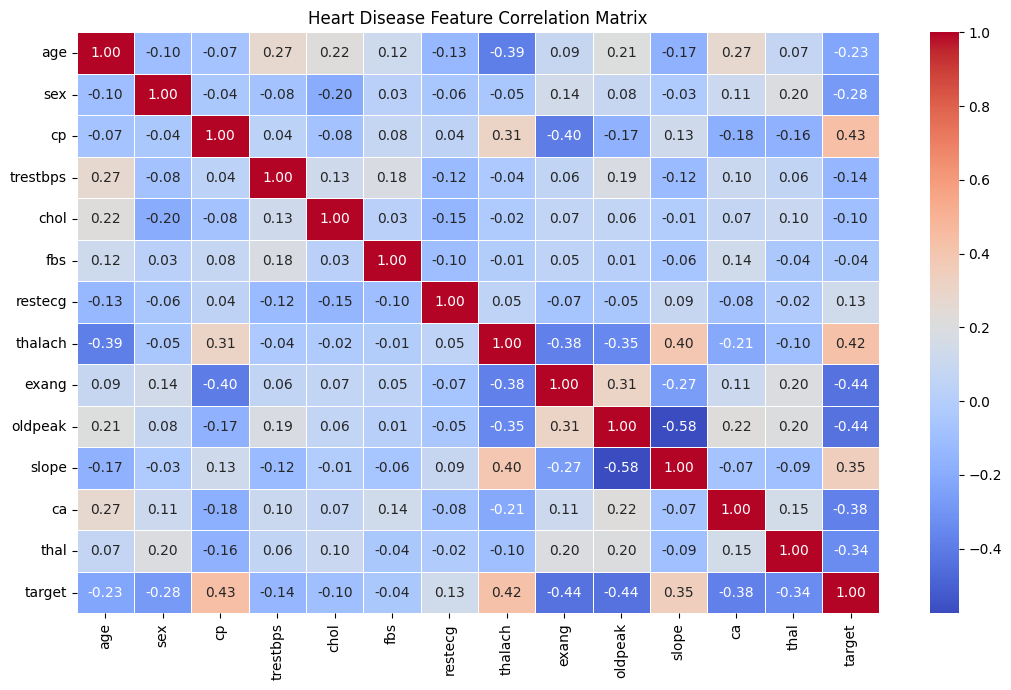

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(11,7))
corr_matrix = data.corr()
sns.heatmap(corr_matrix,annot=True,fmt=".2f",cmap="coolwarm",linewidths=0.4)
plt.title("Heart Disease Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

model_lr = LogisticRegression(random_state=42)
model_rf = RandomForestClassifier(random_state=42)
model_knn = KNeighborsClassifier(n_neighbors=5)
model_lr.fit(X_train_scaled,y_train)
model_rf.fit(X_train_scaled,y_train)
model_knn.fit(X_train_scaled,y_train)


KNeighborsClassifier()

In [16]:
from sklearn.metrics import accuracy_score,precision_score, recall_score,f1_score
import pandas as pd
model_dictionary={"Logistic Regression":model_lr,"Random Forest":model_rf,"KNN Classifier":model_knn}
score_records={}
for model_name,active_model in model_dictionary.items():
  test_predictions = active_model.predict(X_test_scaled)
  score_records[model_name]={
      "Accuracy":accuracy_score(y_test, test_predictions),
      "Precision": precision_score(y_test,test_predictions),
      "Recall": recall_score(y_test,test_predictions),
      "F1-Score": f1_score(y_test, test_predictions)
  }
metrics_table= pd.DataFrame(score_records).T
print(metrics_table)



                     Accuracy  Precision    Recall  F1-Score
Logistic Regression  0.795122   0.756303  0.873786  0.810811
Random Forest        0.985366   1.000000  0.970874  0.985222
KNN Classifier       0.834146   0.800000  0.893204  0.844037


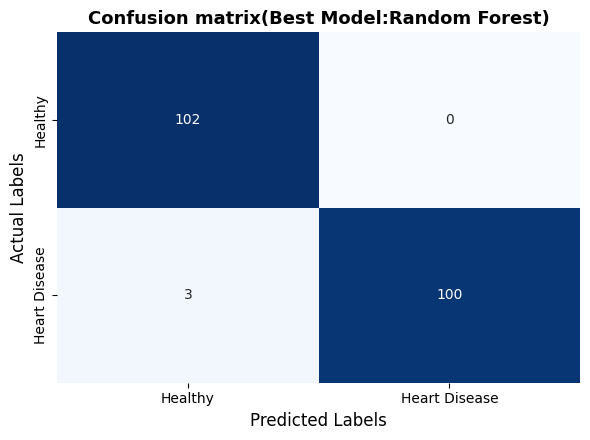

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
rf_preds= model_rf.predict(X_test_scaled)
matrix_data = confusion_matrix(y_test,rf_preds)

plt.figure(figsize=(6,4.5))
sns.heatmap(matrix_data, annot=True,fmt="d",cmap="Blues",cbar=False,
            xticklabels=["Healthy","Heart Disease"],
            yticklabels=["Healthy","Heart Disease"])
plt.xlabel("Predicted Labels",fontsize=12)
plt.ylabel("Actual Labels",fontsize=12)
plt.title("Confusion matrix(Best Model:Random Forest)",fontsize=13,fontweight="bold")
plt.tight_layout()
plt.show()

#Final Conclusion

1. Out of all three tested algorithms, the Random Forest Classifier achieved the highest overall performance, hitting a dominant accuracy score of 98.5%.
2. Random Forest naturally outperformed Logistic Regression (79.5%) and KNN (83.4%) because it uses an ensemble of multiple decision trees to handle complex feature distribuations instead of drawing a single linear boundary.
3. The confusion matrix visually proves the model's reliability,showing an incredibly low error rate with minimal false positives and false negatives on unseen patient profiles.
4. Clinical metrics such as chest pain type(cp)and maximum heart rate achieved(thalach) proved to be key driving indicators for identifying cardiovascular risk.
5. In conclusion, this automated framework demonstrates that tree-based machine learning structures can provide highly accurate predictive baselines to support early clinical diagnostic tools.